In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data_path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/warmflesh_mutual_reg/df_rows_0_0_0_04122025_014710_ncells_6000_Mutual_regulation_or_n_2_3_0_2119a908.csv"
label = "v"
# label = "rows_0_0_0_02122025_210547_ncells_6000_Feed_forward_median_fixed_K_0_2_c0156738.csv"
# Load the event log CSV
df = pd.read_csv(f"{data_path}/event_log_{label}")
df = df.sort_values(["cell", "gene", "time"]).reset_index(drop=True)
df['gene'] = df['gene'] + 1
df.head()

,cell,gene,time,new_state
0,0,1,0.820381,1
1,0,1,0.880904,0
2,0,1,1.958281,1
3,0,1,1.990332,0
4,0,1,2.985686,1


In [26]:
sim_start = 0.0
sim_end = 24   # Duration of twin simulation


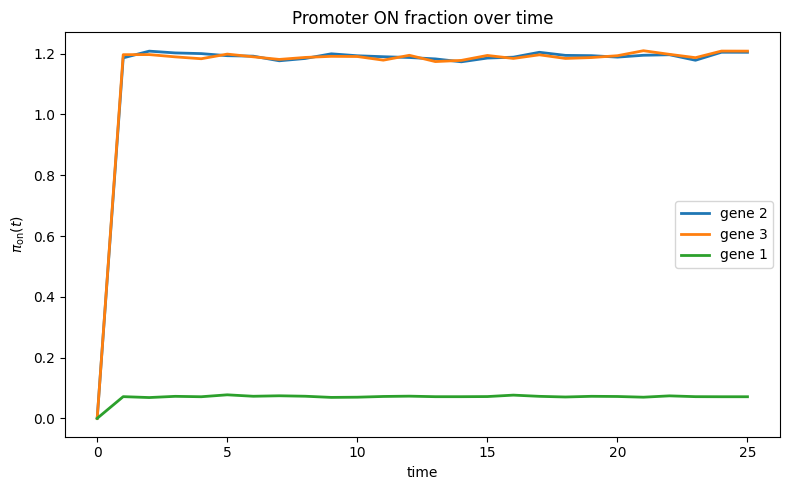

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# 0. INPUT: df with columns: cell, gene, time, new_state
# ================================================================

# Sort ONCE (very fast with mergesort)
df_sorted = df.sort_values("time", kind="mergesort").reset_index(drop=True)

# Unique genes and cells
genes = df_sorted["gene"].unique()
cells = df_sorted["cell"].unique()
num_cells = len(cells)

# Map each cell to a compact index 0..C-1
cell_to_idx_map, uniques = pd.factorize(df_sorted["cell"])
df_sorted["cell_idx"] = cell_to_idx_map  # vectorized, no loop


# ================================================================
# 1. BUILD LIGHTWEIGHT PROMOTER TRACKS
# Each track is an N×3 NumPy array: [time, cell_idx, new_state]
# ================================================================

promoter_tracks = {}

for g in genes:
    sub = df_sorted[df_sorted["gene"] == g]
    promoter_tracks[g] = np.column_stack([
        sub["time"].values,
        sub["cell_idx"].values,
        sub["new_state"].values
    ]).astype(np.float64)   # stores everything together


# ================================================================
# 2. SAMPLING FUNCTION: RECONSTRUCT GENE STATE OVER TIME GRID
# ================================================================

def sample_gene_state(track, time_grid, num_cells):
    """
    track: N×3 array [time, cell_idx, new_state]
    time_grid: array of times to sample
    num_cells: number of unique cells
    returns: T×C matrix of promoter state (0/1)
    """

    # unpack
    event_times = track[:, 0]
    event_cells = track[:, 1].astype(np.int32)
    event_states = track[:, 2].astype(np.int8)

    T = len(time_grid)
    C = num_cells

    curr = np.zeros(C, dtype=np.int8)
    output = np.zeros((T, C), dtype=np.int8)

    e = 0
    E = len(track)

    # sweep through time grid
    for ti, t in enumerate(time_grid):
        # apply all events up to this time
        while e < E and event_times[e] <= t:
            curr[event_cells[e]] = event_states[e]
            e += 1

        output[ti] = curr

    return output

# ================================================================
# 3. SELECT TIME GRID (CHOOSE YOUR RESOLUTION)
# ================================================================

sim_start = df_sorted["time"].min()
sim_end   = df_sorted["time"].max()

# You can also use dt=0.1 or dt=0.01 if needed.
dt = 1.0
time_grid = np.arange(sim_start, sim_end + dt, dt)


# ================================================================
# 4. COMPUTE π_on(t) FOR EACH GENE
# ================================================================

pi_on = {}

for g in genes:
    states = sample_gene_state(promoter_tracks[g], time_grid, num_cells)
    pi_on[g] = states.mean(axis=1)   # fraction ON across cells


# ================================================================
# 5. BUILD RESULT DATAFRAME
# ================================================================

df_pi = pd.DataFrame({"time": time_grid})
for g in genes:
    df_pi[f"gene_{g}"] = pi_on[g]


# ================================================================
# 6. PLOT π_on(t)
# ================================================================

plt.figure(figsize=(8, 5))

for g in genes:
    plt.plot(df_pi["time"], df_pi[f"gene_{g}"], lw=2, label=f"gene {g}")

plt.xlabel("time")
plt.ylabel(r"$\pi_{\mathrm{on}}(t)$")
plt.title("Promoter ON fraction over time")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
pi_on_cell = {g: np.zeros(num_cells) for g in genes}
sim_duration = sim_end - sim_start

for g in genes:
    track = promoter_tracks[g]      # array: [time, cell_idx, new_state]
    times = track[:,0]
    cells_idx = track[:,1].astype(int)
    states = track[:,2].astype(int)

    # Sort by time (just in case)
    order = np.argsort(times)
    times = times[order]
    cells_idx = cells_idx[order]
    states = states[order]

    # For each cell: track current state & last switch time
    curr_state = np.zeros(num_cells, dtype=int)
    last_time = np.full(num_cells, sim_start)

    for t, ci, s in zip(times, cells_idx, states):
        # if the promoter was ON since last_time, accumulate ON time
        if curr_state[ci] == 1:
            pi_on_cell[g][ci] += (t - last_time[ci])

        # update
        curr_state[ci] = s
        last_time[ci] = t

    # Add tail contribution (from last switch to sim_end)
    on_cells = np.where(curr_state == 1)[0]
    pi_on_cell[g][on_cells] += (sim_end - last_time[on_cells])

    # Convert ON time → π_on per cell
    pi_on_cell[g] /= sim_duration

pi_on_avg = {g: pi_on_cell[g].mean() for g in genes}
print(pi_on_avg)


{np.int64(2): np.float64(0.3563150214974016), np.int64(3): np.float64(0.35633061323401405), np.int64(1): np.float64(0.07090778520266984)}


In [7]:
on_times = {}   # (cell, gene) → total ON time

for (cell, gene), sub in df.groupby(["cell", "gene"]):

    sub = sub.sort_values("time")
    times = sub["time"].values
    states = sub["new_state"].values

    prev_t = sim_start
    prev_state = 0      # assume OFF initially
    total = 0.0

    for t, s in zip(times, states):
        # Add ON duration from previous segment
        if prev_state == 1:
            total += t - prev_t

        prev_t = t
        prev_state = s

    # If promoter was ON at end, add the tail to sim_end
    if prev_state == 1:
        total += sim_end - prev_t

    on_times[(cell, gene)] = total


In [ ]:
rows = []
for (cell, gene), tot_on in on_times.items():
    rows.append({"cell": cell, "gene": gene, "time_on": tot_on})

df_on = pd.DataFrame(rows)
df_on["pi_on"] = df_on["time_on"] / (sim_end - sim_start)
df_on.head()

In [ ]:
plt.figure(figsize=(10,6))

for g in genes:
    subset = df_on[df_on["gene"] == g]["time_on"]
    plt.hist(subset, bins=40, alpha=0.5, label=f"Gene {g}")

plt.xlabel("Total ON time")
plt.ylabel("Count")
plt.title("Feed forward AND Distribution of promoter ON-times per gene")
plt.legend()
plt.show()


In [ ]:
simulation_df = pd.read_csv(f"{data_path}/df_{label}")   # <-- replace with your file
simulation_df
plt.figure(figsize=(10,6))
time_vec = df_pi["time"].values
pi_t_1 = df_pi["gene_1"].values
pi_t_2 = df_pi["gene_2"].values
# pi_t_3 = df_pi["gene_3"].values
# pi_t_4 = df_pi["gene_4"].values
pi_on_cell_mean = {g: pi_on_cell[g].mean() for g in genes}

# ============================================================
# THEORETICAL π_on(t) FOR ALL GENES
# ============================================================

k_base_on_1 = 0.66
k_base_on_2 = 0.66
k_base_on_3 = 0.66
k_base_on_4 = 0.66

k_off_1 = 8.6
k_off_2 = 8.6
k_off_3 = 8.6
k_off_4 = 8.6

EC50_1 = 800
EC50_2 = 800
# EC50_2 = 119763.6917
# EC50_3 = 122672.08966666667
n = 2
k_add_1 = 6
k_add_2 = 6
k_add_3 = 6

# Mean protein(t) for each gene from simulation_df
times_sim = simulation_df["time_step"].unique()
times_sim.sort()

g1_vals = simulation_df.groupby("time_step")["gene_1_protein"].mean().values
g2_vals = simulation_df.groupby("time_step")["gene_2_protein"].mean().values
# g3_vals = simulation_df.groupby("time_step")["gene_3_protein"].mean().values    # if needed
# g4_vals = simulation_df.groupby("time_step")["gene_4_protein"].mean().values    # if needed

# Hill function
def hill(x, EC50, n):
    x_n = x**n
    return x_n / (x_n + EC50**n + 1e-12)


# ------------------------------------------------------------
# Gene 1 (no regulation)
# ------------------------------------------------------------
hill_2 = hill(g2_vals, EC50_1, n)
k_on_reg_1 = k_add_2 * hill_2
k_on_1 = k_base_on_1 + k_on_reg_1
pi_theory_1 = k_on_1 / (k_on_1 + k_off_1)

# ------------------------------------------------------------
# Gene 2 (activated by Gene 1)
# ------------------------------------------------------------
hill_1 = hill(g1_vals, EC50_1, n)
k_on_reg_2 = k_add_2 * hill_1
k_on_2 = k_base_on_2 + k_on_reg_2
pi_theory_2 = k_on_2 / (k_on_2 + k_off_2)

# ------------------------------------------------------------
# # Gene 3 (activated by Gene 2)
# # ------------------------------------------------------------
# hill_1_to_3 = hill(g1_vals, EC50_1, n)
# hill_2_to_3 = hill(g2_vals, EC50_2, n)

# k_on_reg_3 = k_add_2 * hill_2_to_3
# k_on_3 = k_base_on_3 + k_on_reg_3

# pi_theory_3 = k_on_3 / (k_on_3 + k_off_3)

# # ------------------------------------------------------------
# # Gene 4 (activated by Gene 3)
# # ------------------------------------------------------------
# hill_3_to_4 = hill(g3_vals, EC50_3, n)

# k_on_reg_4 = k_add_3 * hill_3_to_4
# k_on_4 = k_base_on_4 + k_on_reg_4

# pi_theory_4 = k_on_4 / (k_on_4 + k_off_4)

# -------------------------
# Gene 1
# -------------------------
plt.plot(time_vec, pi_t_1, lw=2, label="Gene 1 empirical π_on(t)", color="blue")

plt.hlines(
    pi_on_cell_mean[1],          # value
    xmin=time_vec.min(),
    xmax=time_vec.max(),
    colors="blue",
    linestyles=":",
    linewidth=2,
    label="Gene 1 mean π_on (per-cell)"
)

plt.plot(
    times_sim,
    pi_theory_1,
    "--",
    lw=2,
    color="blue",
    label="Gene 1 theoretical π_on"
)

# -------------------------
# Gene 2
# -------------------------
plt.plot(time_vec, pi_t_2, lw=2, label="Gene 2 empirical π_on(t)", color="red")
plt.hlines(pi_on_cell_mean[2], time_vec.min(), time_vec.max(),
           colors="red", linestyles=":", linewidth=2, label="Gene 2 mean π_on (per-cell)")
plt.plot(times_sim, pi_theory_2, "--", lw=2, color="red", label="Gene 2 theoretical π_on")

# -------------------------
# Gene 3
# -------------------------
# plt.plot(time_vec, pi_t_3, lw=2, label="Gene 3 empirical π_on(t)", color="green")
# plt.hlines(pi_on_cell_mean[3], time_vec.min(), time_vec.max(),
#            colors="green", linestyles=":", linewidth=2, label="Gene 3 mean π_on (per-cell)")
# plt.plot(times_sim, pi_theory_3, "--", lw=2, color="green", label="Gene 3 theoretical π_on")

# -------------------------
# Gene 4
# -------------------------
# plt.plot(time_vec, pi_t_4, lw=2, label="Gene 4 empirical π_on(t)", color="orange")
# plt.hlines(pi_on_cell_mean[4], time_vec.min(), time_vec.max(),
#            colors="orange", linestyles=":", linewidth=2, label="Gene 4 mean π_on (per-cell)")
# plt.plot(times_sim, pi_theory_4, "--", lw=2, color="orange", label="Gene 4 theoretical π_on")

# Final plot formatting
plt.xlabel("Time")
plt.ylabel(r"$\pi_{\mathrm{on}}$")
plt.title("A <-> B (K not steady state value) empirical instantaneous π_on(t), per-cell π_on, and theoretical π_on")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

def compute_means_chunked(path, n_genes, min_time=0):
    """
    Ultra-low-memory timepoint mean calculator.
    Reads CSV in chunks and accumulates sums per timepoint.
    """

    sums = {}  # key = time_step, value = [sum_gene1, sum_gene2, ..., count]

    for chunk in pd.read_csv(path, chunksize=200000):
        # OPTIONAL filtering inside chunk
        chunk = chunk[chunk['time_step'] > min_time]

        for t, group in chunk.groupby('time_step'):
            if t not in sums:
                sums[t] = [0.0] * n_genes + [0]   # N genes + count

            sums[t][-1] += len(group)

            for i in range(n_genes):
                sums[t][i] += group[f'gene_{i+1}_protein'].sum()

    # Convert accumulated sums to means
    t_list = sorted(sums.keys())
    means = [[] for _ in range(n_genes)]

    for t in t_list:
        count = sums[t][-1]
        for i in range(n_genes):
            means[i].append(sums[t][i] / count)

    return t_list, means


# # ---- RUN NOW ----
n_genes = 2

fin_path = f"{data_path}/df_{label}"
# org_path = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/testing_hill/df_rows_0_0_0_0_0_03122025_192023_ncells_6000_Five_gene_cascade_fixed_K_0_0_ee07b57b.csv"

# print("Processing FIN...")
t_list_fin, mean_val_fin = compute_means_chunked(fin_path, n_genes)

# print("Processing ORG...")
# t_list_org, mean_val_org = compute_means_chunked(org_path, n_genes)

# Use ORG time list for plotting (or FIN)
t_list_fin_norm = t_list_fin
# t_list_org_norm = t_list_org


# ---- PLOT ----
plt.figure(figsize=(12, 8))
colors = ['blue', 'orange', 'green', 'purple', 'red']
k_prod = 2
k_deg = 0.17328679513998632
k_prod_prot = 560
k_deg_prot = 0.015403270679109895
proteins = [[],[]]
mRNA_1 = k_prod*pi_theory_1/k_deg
proteins[0] = k_prod_prot*mRNA_1/k_deg_prot
mRNA_2 = k_prod*pi_theory_2/k_deg
proteins[1] = k_prod_prot*mRNA_2/k_deg_prot

# EC50 = [29906.979604393327,125265.1379158951, 125265.1379158951, 125265.1379158951]
# EC50 = [29906.979604393327, 183129.9181232677, 183129.9181232677]
for i in range(n_genes):
    if i == 2:
        plt.plot(t_list_fin_norm, mean_val_fin[i], color=colors[i], linewidth=2,linestyle = ":",
             label=f"Protein {i+1}")
        # plt.axhline(EC50[i], color=colors[i], linewidth=2, linestyle = "-.",
        #         label=f"K for gene {i+1}")
    else:
        plt.plot(t_list_fin_norm, mean_val_fin[i], color=colors[i], linewidth=2,
                label=f"Protein {i+1}")
        # plt.axhline(EC50[i], color=colors[i], linewidth=2, linestyle = "--",
        #         label=f"K for gene {i+1}")
    # plt.plot(t_list_org_norm, mean_val_org[i], color=colors[i], linewidth=2,
    #          linestyle = "--", label=f"K not steady state Gene {i+1}")

plt.xlabel("Time (h)")
plt.ylabel("Protein Amount")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for i in range(n_genes):
    mean_arr = np.array(mean_val_fin[i])
    # mean_arr_org = np.array(mean_val_org[i])
    # EC50_arr = np.full(len(mean_arr), EC50[i])
    print(np.mean(mean_arr))
    # plt.plot(
    #     t_list_fin_norm,
    #     100 * (mean_arr_org - mean_arr) / mean_arr_org,
    #     color=colors[i], linewidth=2,
    #     label=f"Protein {i+1}"
    # )

# plt.xlabel("Time (h)")
# plt.ylabel("Error Percentage between the two runs")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

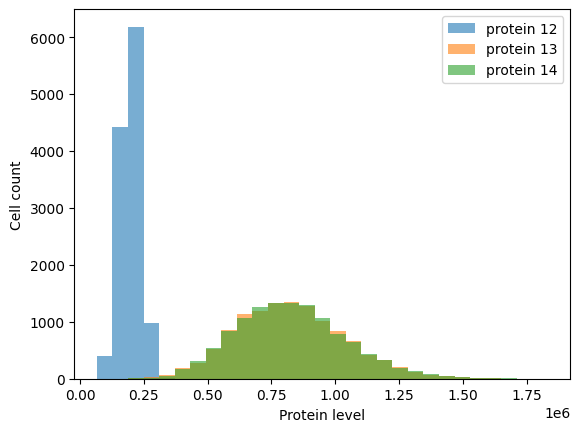

In [22]:
fin_path = f"{data_path}/df_{label}"
df = pd.read_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_1_network/df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0_05122025_091621_ncells_6000_figure_1_network_1_1_9ba4fcce.csv")

df = df[df['time_step'] == 1]

# Compute global min/max for binning
all_values = np.concatenate([
    df['gene_12_protein'].values,
    df['gene_13_protein'].values,
    df['gene_14_protein'].values
])

# Choose number of bins
bins = np.linspace(all_values.min(), all_values.max(), 30)

# Plot all histograms using SAME bins
plt.hist(df['gene_12_protein'], bins=bins, label="protein 12", alpha=0.6)
plt.hist(df['gene_13_protein'], bins=bins, label="protein 13", alpha=0.6)
plt.hist(df['gene_14_protein'], bins=bins, label="protein 14", alpha=0.6)

plt.ylabel("Cell count")
plt.xlabel("Protein level")
plt.legend()
plt.show()


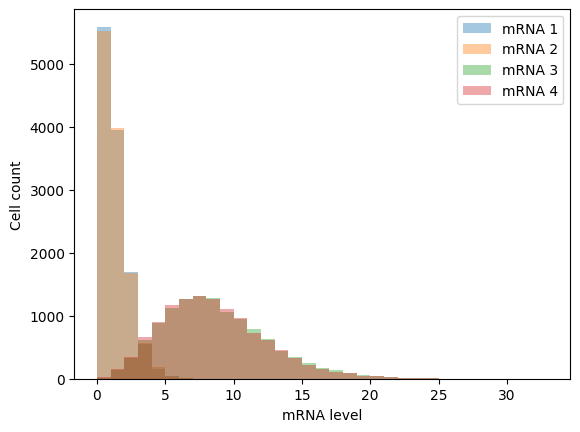

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim/df_rows_0_0_0_0_05122025_134818_ncells_6000_Bi_fan_or_n_2_0_0_317ba259.csv")

df = df[df['time_step'] == 1]

all_values = np.concatenate([
    df['gene_1_mRNA'].values,
    df['gene_2_mRNA'].values,
    df['gene_3_mRNA'].values,
    df['gene_4_mRNA'].values
])

# Choose number of bins
bins = np.arange(all_values.min(), all_values.max() + 1, 1)

plt.hist(df['gene_1_mRNA'],bins=bins, label = "mRNA 1", alpha = 0.4)
plt.hist(df['gene_2_mRNA'],bins=bins, label = "mRNA 2", alpha = 0.4)
plt.hist(df['gene_3_mRNA'],bins=bins, label = "mRNA 3", alpha = 0.4)
plt.hist(df['gene_4_mRNA'],bins=bins, label = "mRNA 4", alpha = 0.4)
plt.ylabel("Cell count")
plt.xlabel("mRNA level")
plt.legend()
plt.show()